In [2]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

In [3]:
# Load your generated JSON
with open("./inputFinal.json", "r", encoding="utf-8") as f:
    data = json.load(f)

df = pd.DataFrame(data)

# Basic metrics
df["num_questions"] = df["questions"].apply(len)
df["lines_of_code"] = df["code"].apply(lambda x: len(x.splitlines()))


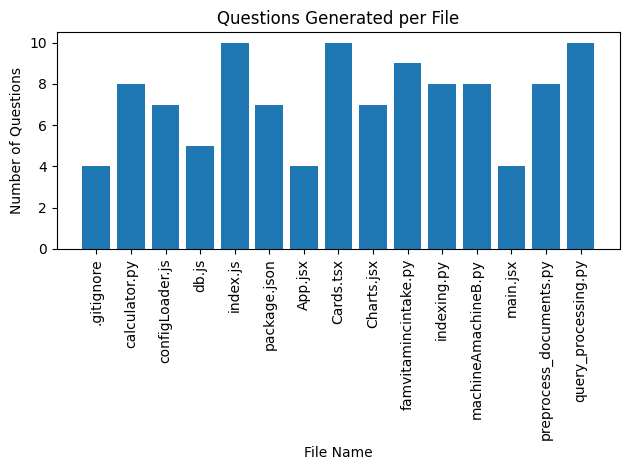

In [4]:
plt.figure()
plt.bar(df["file_name"], df["num_questions"])
plt.xticks(rotation=90)
plt.xlabel("File Name")
plt.ylabel("Number of Questions")
plt.title("Questions Generated per File")
plt.tight_layout()
plt.show()

In [7]:
# plt.figure()
# plt.hist(df["num_questions"])
# plt.xlabel("Number of Questions")
# plt.ylabel("Number of Files")
# plt.title("Distribution of Questions per File")
# plt.show()

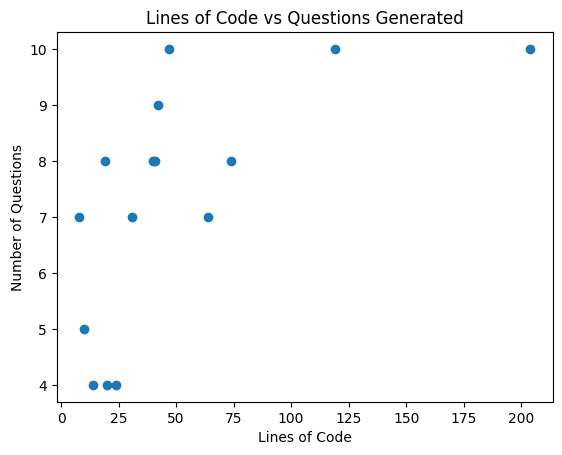

In [6]:
plt.figure()
plt.scatter(df["lines_of_code"], df["num_questions"])
plt.xlabel("Lines of Code")
plt.ylabel("Number of Questions")
plt.title("Lines of Code vs Questions Generated")
plt.show()

In [9]:
# df["questions_per_100_loc"] = (df["num_questions"] / df["lines_of_code"]) * 100

# plt.figure()
# plt.bar(df["file_name"], df["questions_per_100_loc"])
# plt.xticks(rotation=90)
# plt.xlabel("File Name")
# plt.ylabel("Questions per 100 LOC")
# plt.title("Question Density by File")
# plt.tight_layout()
# plt.show()

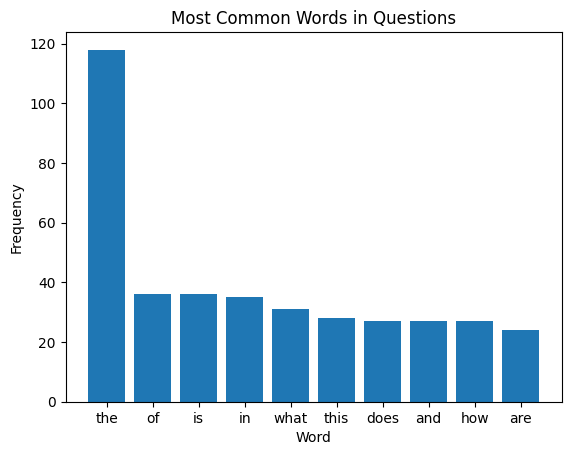

In [14]:
all_questions = " ".join(
    q.lower() for questions in df["questions"] for q in questions
)

words = all_questions.split()
common_words = Counter(words).most_common(10)

labels, values = zip(*common_words)

plt.figure()
plt.bar(labels, values)
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.title("Most Common Words in Questions")
plt.show()


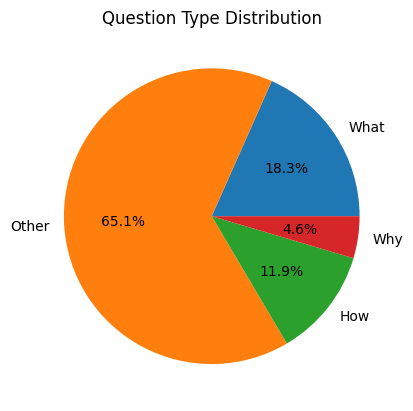

In [11]:
def question_type(q):
    q = q.lower()
    if q.startswith("why"):
        return "Why"
    if q.startswith("how"):
        return "How"
    if q.startswith("what"):
        return "What"
    if q.startswith("when"):
        return "When"
    return "Other"

types = [
    question_type(q)
    for questions in df["questions"]
    for q in questions
]

type_counts = Counter(types)

plt.figure()
plt.pie(type_counts.values(), labels=type_counts.keys(), autopct="%1.1f%%")
plt.title("Question Type Distribution")
plt.show()


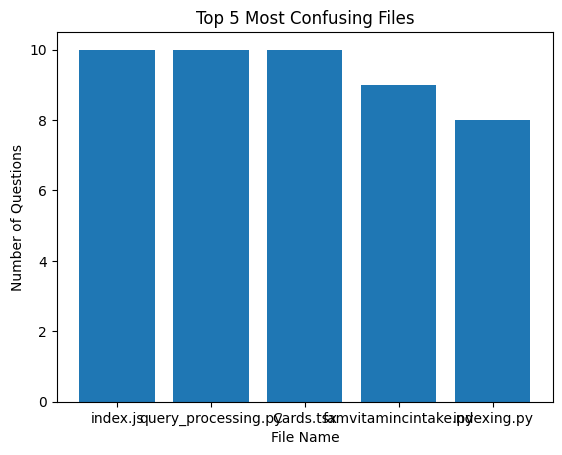

In [12]:
top_files = df.sort_values("num_questions", ascending=False).head(5)

plt.figure()
plt.bar(top_files["file_name"], top_files["num_questions"])
plt.xlabel("File Name")
plt.ylabel("Number of Questions")
plt.title("Top 5 Most Confusing Files")
plt.show()
